---
title: "Melbourne Real Estate Analysis "
author: "Hoang Son Lai"
date: "05/15/2026"
categories: [Exploratory Data Analysis, Machine Learning]
format: 
 html:
  toc: true
  css: styles.css
  embed-resources: true
  code-fold: true
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# To convert to html, quarto render report.ipynb

In [2]:
# Load Data
df = pd.read_csv('../data/melbourne_price_data_enriched.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (163430, 27)


,Property_ID,Status,Full_Address,Suburb,Postcode,Property_Type,Date,Beds,Baths,Car_Spaces,...,URL,Last_Updated,abs_median_income_weekly,abs_median_age,abs_population,crime_offence_count,crime_suburb_ref,crime_rate_per_100k,dist_nearest_train_km,Enriched_Date
0,2010114712,Sold,"695 Mount Blackwood Road, KOROBEIT VIC 3341",KOROBEIT,3341,House,10 Dec 2012,3,1,2,...,https://www.domain.com.au/695-mount-blackwood-...,2026-03-17,861,43,1644,68.0,Myrniong,4136.3,11.159,2026-05-02
1,2011918466,Sold,"70 Lohs Lane, MYRNIONG VIC 3341",MYRNIONG,3341,House,18 May 2015,4,2,4,...,https://www.domain.com.au/70-lohs-lane-myrnion...,2026-03-17,861,43,1644,68.0,Myrniong,4136.3,10.663,2026-05-02
2,2013015017,Sold,"89 Lohs Lane, MYRNIONG VIC 3341",MYRNIONG,3341,House,03 Oct 2016,3,2,2,...,https://www.domain.com.au/89-lohs-lane-myrnion...,2026-03-17,861,43,1644,68.0,Myrniong,4136.3,10.748,2026-05-02


In [3]:
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:
Property_Type             87
Date                   38600
LandSize_sqm              87
Raw_Price                 87
Numeric_Price          15739
crime_offence_count       26
crime_suburb_ref          26
crime_rate_per_100k       26
dtype: int64


In [4]:
# Parse Date
df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Sale_Year']  = df['Date_parsed'].dt.year
df['Sale_Month'] = df['Date_parsed'].dt.month

n_valid = df['Date_parsed'].notna().sum()
print(f"Valid dates parsed: {n_valid:,} / {len(df):,} ({n_valid/len(df)*100:.1f}%)")

Valid dates parsed: 124,787 / 163,430 (76.4%)


In [5]:
# Numeric Price Cleaning
print("Price distribution before cleaning:")
print(df['Numeric_Price'].describe())

# Flag extreme low outliers — likely data entry errors, not real sales
LOW_THRESHOLD = 10_000
mask_low = df['Numeric_Price'] < LOW_THRESHOLD
print(f"\nRows with price < ${LOW_THRESHOLD:,}: {mask_low.sum()}")
df.loc[mask_low, 'Numeric_Price'] = np.nan

# High outlier
upper_cap = df['Numeric_Price'].quantile(0.995)
print(f"99.5th percentile cap: ${upper_cap:,.0f}")
# We will apply this cap later on the Sold training set only — not here globally.

Price distribution before cleaning:
count    1.476910e+05
mean     9.940362e+05
std      2.304724e+06
min      1.000000e+00
25%      6.204135e+05
50%      7.700000e+05
75%      1.087500e+06
max      5.805000e+08
Name: Numeric_Price, dtype: float64

Rows with price < $10,000: 48
99.5th percentile cap: $5,050,000


In [6]:
# Property Type Grouping
type_map = {
    'House':                          'House',
    'Townhouse':                      'Townhouse',
    'Apartment / Unit / Flat':        'Apartment',
    'Villa':                          'Villa',
    'Studio':                         'Apartment',
    'Penthouse':                      'Apartment',
    'Semi-Detached':                  'House',
    'Duplex':                         'House',
    'Terrace':                        'House',
    'Block of Units':                 'Apartment',
    'New House & Land':               'New House & Land',
    'New Home Designs':               'House',
    'New Apartments / Off the Plan':  'Apartment',
    'New land':                       'New Land',
    'Vacant land':                    'Vacant Land',
    'Acreage / Semi-Rural':           'Rural',
    'Rural':                          'Rural',
    'Rural Lifestyle':                'Rural',
    'Farm':                           'Rural',
    'Farmlet':                        'Rural',
    'Grazing':                        'Rural',
    'Livestock':                      'Rural',
    'Specialist Farm':                'Rural',
    'Development Site':               'Other',
    'Car Space':                      'Other',
    'Unknown':                        'Other',
}

df['Property_Group'] = df['Property_Type'].map(type_map).fillna('Other')
print(df['Property_Group'].value_counts())

Property_Group
House               104981
Apartment            21424
Townhouse            12348
Vacant Land          10997
New House & Land     10610
Rural                 2251
Villa                  376
Other                  243
New Land               200
Name: count, dtype: int64


In [7]:
# Flag vacant / land-type properties
df['Is_Land'] = df['Property_Group'].isin(['Vacant Land', 'New Land', 'New House & Land']).astype(int)

# LandSize = 0 for apartments is plausible (strata title, no individual land)
# LandSize = 0 for houses/townhouses is suspicious — set to NaN
mask_land_zero = (df['LandSize_sqm'] == 0) & (~df['Is_Land'].astype(bool)) & (df['Property_Group'].isin(['House', 'Townhouse']))
print(f"House/Townhouse rows with LandSize = 0 set to NaN: {mask_land_zero.sum():,}")
df.loc[mask_land_zero, 'LandSize_sqm'] = np.nan

print(f"\nLandSize missing after fix: {df['LandSize_sqm'].isna().sum():,}")

House/Townhouse rows with LandSize = 0 set to NaN: 31,525

LandSize missing after fix: 31,612


In [8]:
# Split: Sold vs For Sale
sold    = df[df['Status'] == 'Sold'].copy()
forsale = df[df['Status'] == 'For Sale'].copy()

print(f"Sold:     {len(sold):,} rows")
print(f"For Sale: {len(forsale):,} rows")

# For ML, we need a known price — drop Sold rows where price is withheld
sold_ml = sold.dropna(subset=['Numeric_Price']).copy()
print(f"Sold with known price (for ML): {len(sold_ml):,} rows")

Sold:     124,896 rows
For Sale: 38,534 rows
Sold with known price (for ML): 114,566 rows


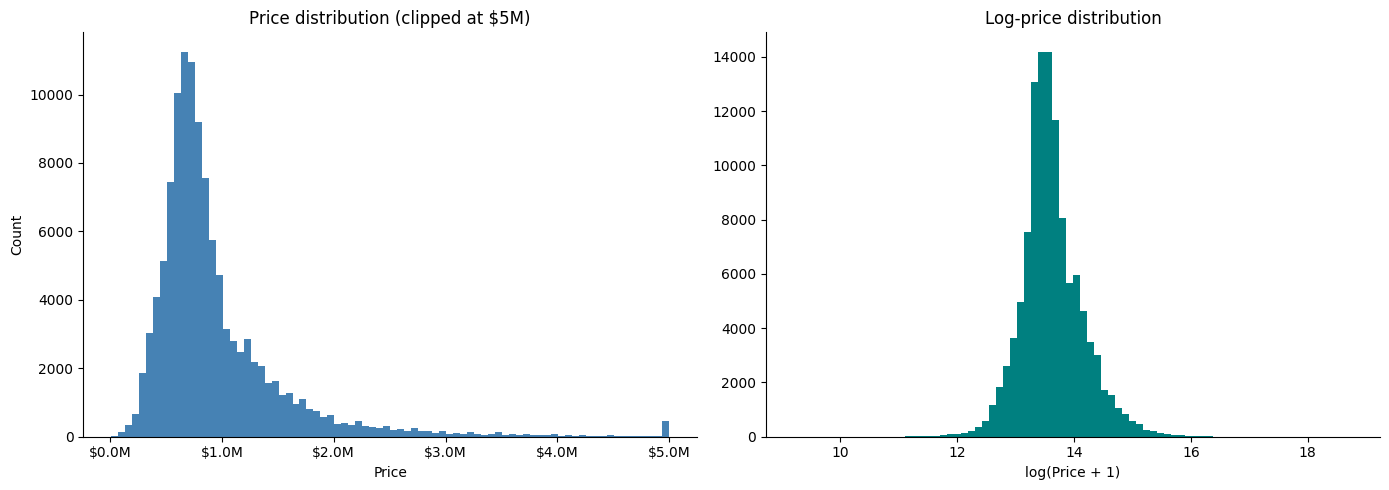

count        $114,566
mean         $965,624
std        $1,067,642
min           $10,000
25%          $610,000
50%          $772,000
75%        $1,082,000
max      $140,000,000
Name: Numeric_Price, dtype: str


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale
axes[0].hist(sold_ml['Numeric_Price'].clip(upper=5e6), bins=80, color='steelblue', edgecolor='none')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_title('Price distribution (clipped at $5M)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Log scale — closer to normal, better for modelling
axes[1].hist(np.log1p(sold_ml['Numeric_Price']), bins=80, color='teal', edgecolor='none')
axes[1].set_title('Log-price distribution')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

print(sold_ml['Numeric_Price'].describe().apply(lambda x: f'${x:,.0f}'))

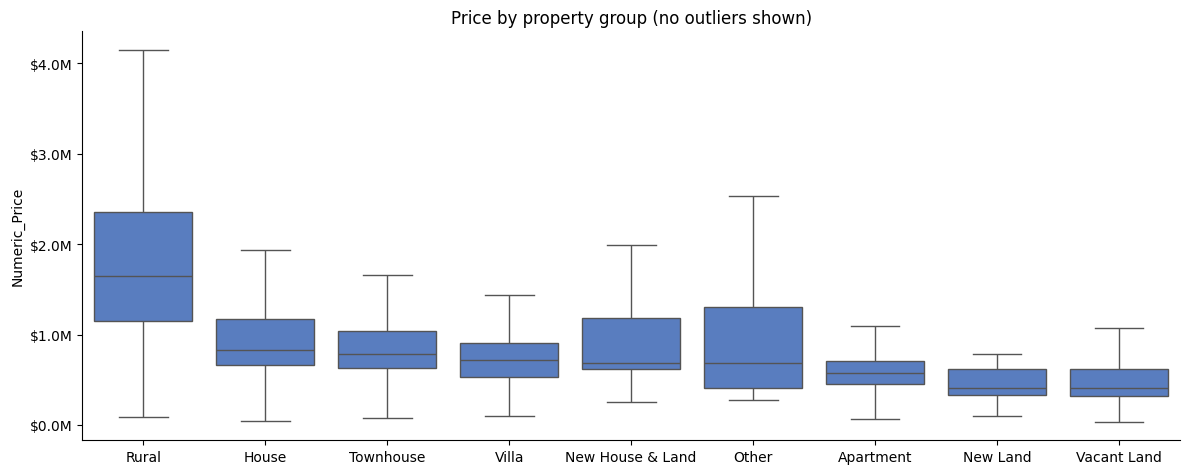

In [10]:
order = sold_ml.groupby('Property_Group')['Numeric_Price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=sold_ml,
    x='Property_Group',
    y='Numeric_Price',
    order=order,
    showfliers=False,
    patch_artist=True
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Price by property group (no outliers shown)')
ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

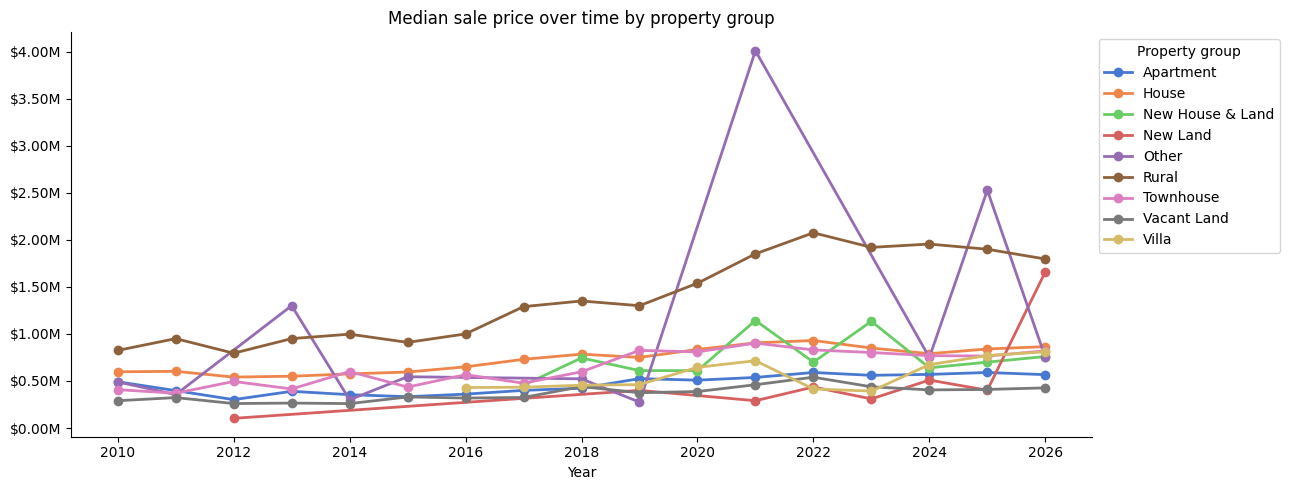

In [11]:
yearly = (
    sold_ml[sold_ml['Sale_Year'].between(2010, 2026)]
    .groupby(['Sale_Year', 'Property_Group'])['Numeric_Price']
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
for grp, sub in yearly.groupby('Property_Group'):
    ax.plot(sub['Sale_Year'], sub['Numeric_Price'], marker='o', label=grp, linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
ax.set_title('Median sale price over time by property group')
ax.set_xlabel('Year')
ax.legend(title='Property group', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

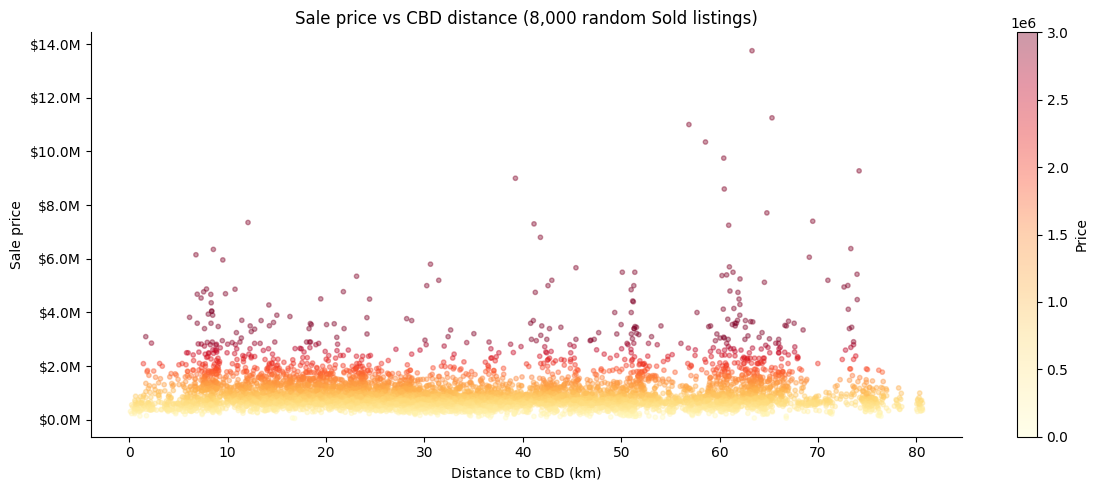

In [12]:
sample = sold_ml.dropna(subset=['Distance_to_CBD_km', 'Numeric_Price']).sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 5))
scatter = ax.scatter(
    sample['Distance_to_CBD_km'],
    sample['Numeric_Price'],
    c=sample['Numeric_Price'],
    cmap='YlOrRd',
    alpha=0.4,
    s=10,
    norm=plt.Normalize(vmin=0, vmax=3e6)
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlabel('Distance to CBD (km)')
ax.set_ylabel('Sale price')
ax.set_title('Sale price vs CBD distance (8,000 random Sold listings)')
plt.colorbar(scatter, ax=ax, label='Price')
plt.tight_layout()
plt.show()

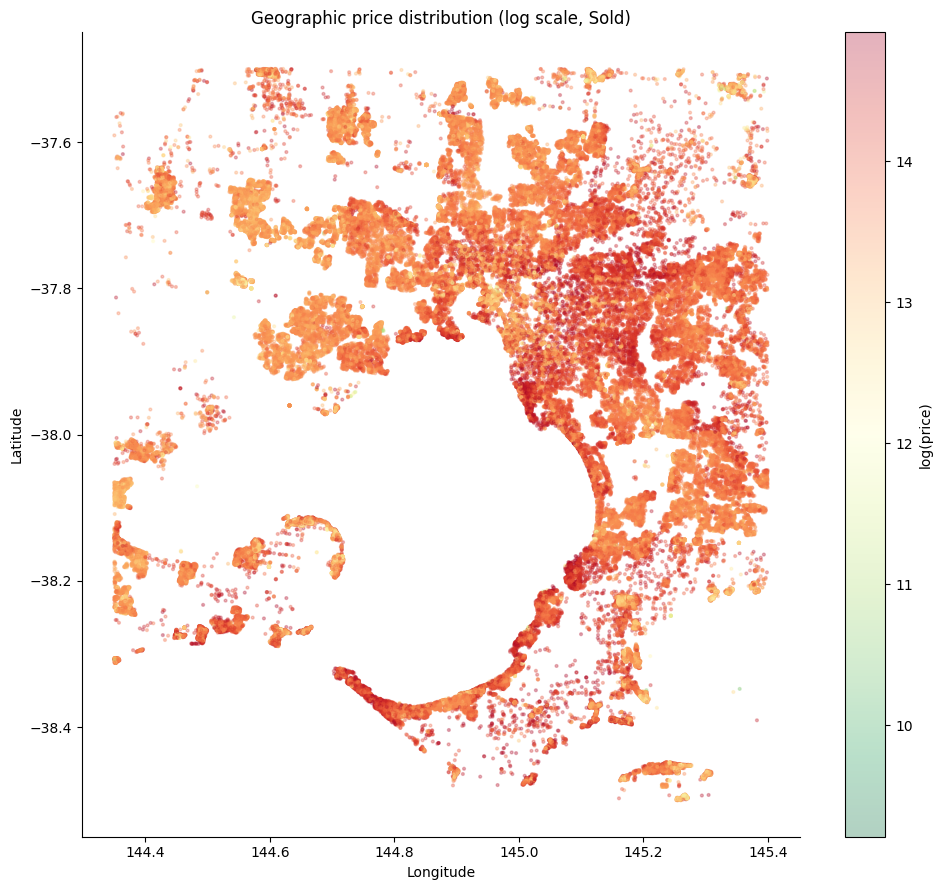

In [13]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 9))

sample_geo = sold_ml.dropna(subset=['Latitude', 'Longitude', 'Numeric_Price'])
sample_geo = sample_geo[sample_geo['Numeric_Price'] < 3e6]

sc = ax.scatter(
    sample_geo['Longitude'],
    sample_geo['Latitude'],
    c=np.log1p(sample_geo['Numeric_Price']),
    cmap='RdYlGn_r',
    alpha=0.3,
    s=4
)
ax.set_title('Geographic price distribution (log scale, Sold)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(sc, ax=ax, label='log(price)')
plt.tight_layout()
plt.show()

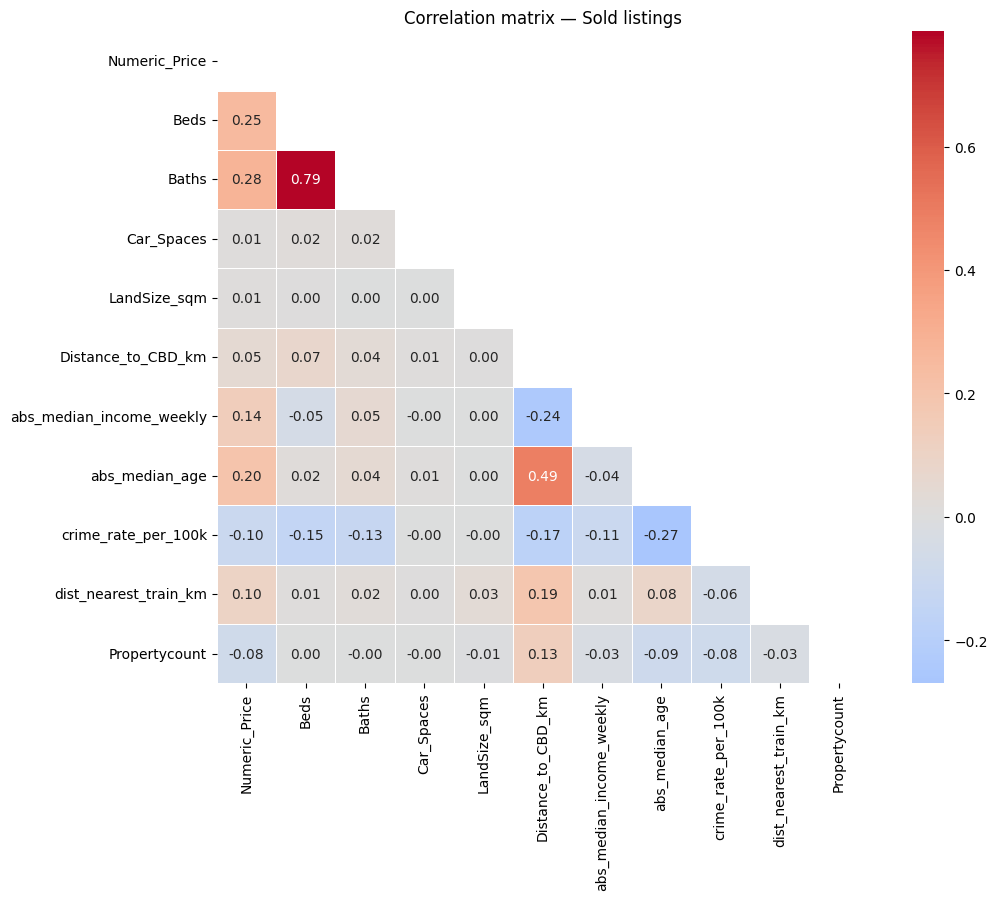

In [14]:
corr_cols = [
    'Numeric_Price', 'Beds', 'Baths', 'Car_Spaces', 'LandSize_sqm',
    'Distance_to_CBD_km', 'abs_median_income_weekly', 'abs_median_age',
    'crime_rate_per_100k', 'dist_nearest_train_km', 'Propertycount'
]

corr_data = sold_ml[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Correlation matrix — Sold listings')
plt.tight_layout()
plt.show()

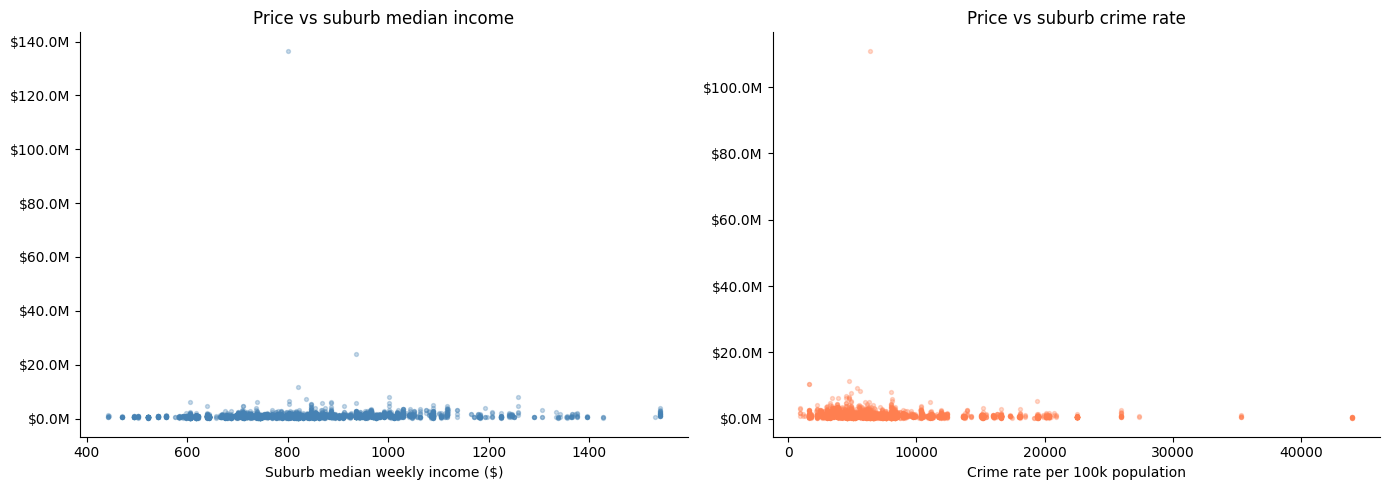

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income
axes[0].scatter(
    sold_ml['abs_median_income_weekly'].sample(5000, random_state=1),
    sold_ml.loc[sold_ml['abs_median_income_weekly'].sample(5000, random_state=1).index, 'Numeric_Price'],
    alpha=0.3, s=8, color='steelblue'
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_xlabel('Suburb median weekly income ($)')
axes[0].set_title('Price vs suburb median income')

# Crime
axes[1].scatter(
    sold_ml['crime_rate_per_100k'].sample(5000, random_state=2),
    sold_ml.loc[sold_ml['crime_rate_per_100k'].sample(5000, random_state=2).index, 'Numeric_Price'],
    alpha=0.3, s=8, color='coral'
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].set_xlabel('Crime rate per 100k population')
axes[1].set_title('Price vs suburb crime rate')

plt.tight_layout()
plt.show()

For Sale with numeric price: 33,077 / 38,534
(Remainder show price ranges or 'Contact Agent')


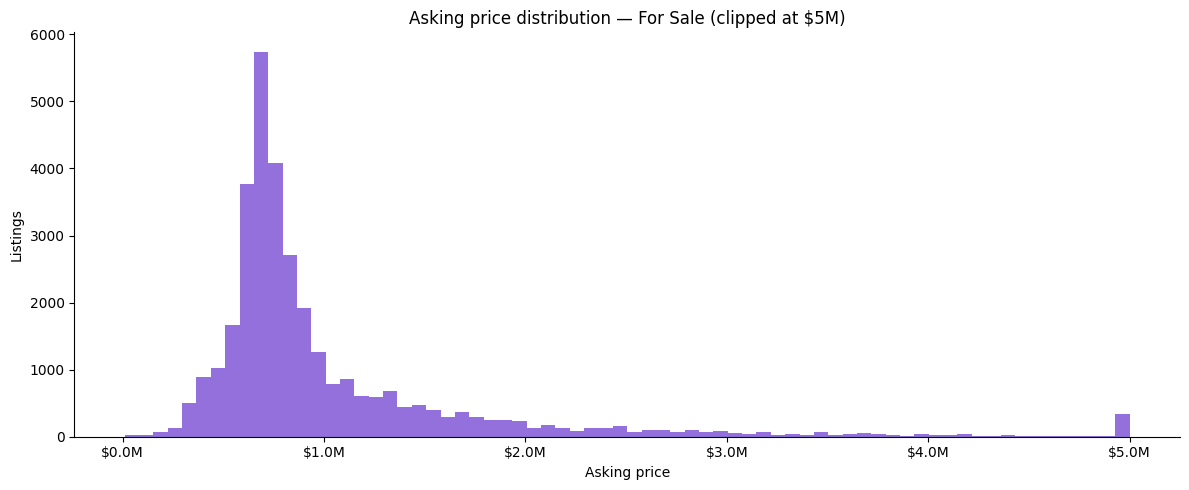

In [16]:
fs_priced = forsale.dropna(subset=['Numeric_Price'])
print(f"For Sale with numeric price: {len(fs_priced):,} / {len(forsale):,}")
print(f"(Remainder show price ranges or 'Contact Agent')")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fs_priced['Numeric_Price'].clip(upper=5e6), bins=70, color='mediumpurple', edgecolor='none')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Asking price distribution — For Sale (clipped at $5M)')
ax.set_xlabel('Asking price')
ax.set_ylabel('Listings')
plt.tight_layout()
plt.show()

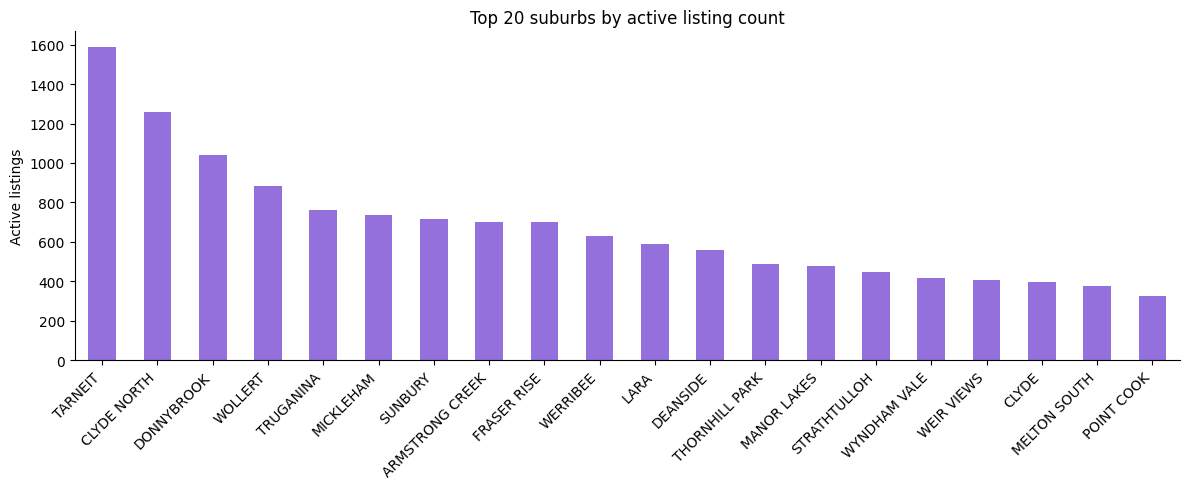

In [17]:
suburb_inventory = forsale['Suburb'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 5))
suburb_inventory.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='none')
ax.set_title('Top 20 suburbs by active listing count')
ax.set_xlabel('')
ax.set_ylabel('Active listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

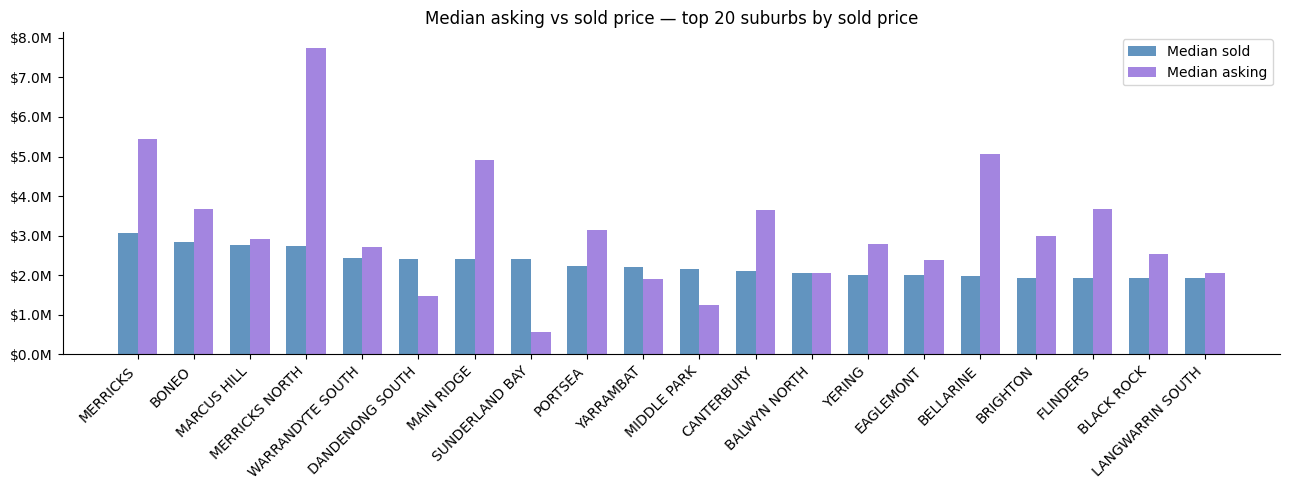


Suburbs with highest asking premium over sold median:
                   median_sold  median_asking  premium_pct
Suburb                                                    
WARNEET               515000.0      1837500.0   256.796117
COLDSTREAM            900000.0      3100000.0   244.444444
OAKLANDS JUNCTION     910000.0      3045000.0   234.615385
EAST MELBOURNE        855000.0      2750000.0   221.637427
TOORAK                887500.0      2850000.0   221.126761
EDEN PARK             850000.0      2500000.0   194.117647
CARLTON               450000.0      1300000.0   188.888889
RED HILL             1390000.0      3990000.0   187.050360
MERRICKS NORTH       2735000.0      7750000.0   183.363803
PARWAN                775000.0      2100000.0   170.967742


In [18]:
sold_suburb_median = (
    sold_ml.groupby('Suburb')['Numeric_Price']
    .median()
    .rename('median_sold')
)
fs_suburb_median = (
    fs_priced.groupby('Suburb')['Numeric_Price']
    .median()
    .rename('median_asking')
)

compare = pd.concat([sold_suburb_median, fs_suburb_median], axis=1).dropna()
compare['premium_pct'] = (compare['median_asking'] - compare['median_sold']) / compare['median_sold'] * 100

top_suburbs = compare.nlargest(20, 'median_sold')

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top_suburbs))
w = 0.35
ax.bar(x - w/2, top_suburbs['median_sold'],     w, label='Median sold',   color='steelblue',    alpha=0.85)
ax.bar(x + w/2, top_suburbs['median_asking'],   w, label='Median asking', color='mediumpurple', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_suburbs.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Median asking vs sold price — top 20 suburbs by sold price')
ax.legend()
plt.tight_layout()
plt.show()

print("\nSuburbs with highest asking premium over sold median:")
print(compare.sort_values('premium_pct', ascending=False).head(10).to_string())

In [19]:
def build_features(df_in):
    d = df_in.copy()

    # --- Rooms ---
    # Note: Beds = 0 and Baths = 0 is valid for Land/Rural properties.
    # We keep them as-is and rely on Is_Land flag to provide context.
    d['Total_Rooms']  = d['Beds'] + d['Baths']
    d['Bath_per_Bed'] = np.where(d['Beds'] > 0, d['Baths'] / d['Beds'], 0)

    # --- Land ---
    d['Log_LandSize'] = np.log1p(d['LandSize_sqm'].fillna(0))

    # --- Location zones ---
    d['CBD_Zone'] = pd.cut(
        d['Distance_to_CBD_km'],
        bins=[0, 10, 20, 35, np.inf],
        labels=['inner', 'middle', 'outer', 'regional']
    )

    # --- Suburb-level statistics (from sold data only — avoid leakage) ---
    # These are computed externally on sold_ml and then merged in.
    # See next cell.

    # --- Log transforms for skewed continuous features ---
    d['Log_Crime']     = np.log1p(d['crime_rate_per_100k'].fillna(d['crime_rate_per_100k'].median()))
    d['Log_Income']    = np.log1p(d['abs_median_income_weekly'])
    d['Log_Train_Dist']= np.log1p(d['dist_nearest_train_km'])

    return d

sold_ml  = build_features(sold_ml)
forsale  = build_features(forsale)

In [20]:
# Suburb median price encoding — computed ONLY on sold_ml to avoid leakage.
# This encodes "what has this suburb historically sold for".
# Smoothed with global mean to handle low-count suburbs.
global_mean = sold_ml['Numeric_Price'].mean()
suburb_stats = (
    sold_ml.groupby('Suburb')['Numeric_Price']
    .agg(['median', 'count'])
    .rename(columns={'median': 'suburb_median_price', 'count': 'suburb_sold_count'})
)

# Smoothing: blend suburb median toward global mean for suburbs with < 20 sales
k = 20
suburb_stats['suburb_median_smooth'] = (
    (suburb_stats['suburb_median_price'] * suburb_stats['suburb_sold_count'] + global_mean * k) /
    (suburb_stats['suburb_sold_count'] + k)
)

sold_ml  = sold_ml.merge(suburb_stats[['suburb_median_smooth', 'suburb_sold_count']], on='Suburb', how='left')
forsale  = forsale.merge(suburb_stats[['suburb_median_smooth', 'suburb_sold_count']], on='Suburb', how='left')

# Unseen suburbs in For Sale get the global mean
forsale['suburb_median_smooth'] = forsale['suburb_median_smooth'].fillna(global_mean)
forsale['suburb_sold_count']    = forsale['suburb_sold_count'].fillna(0)

print("Feature engineering done.")
print(f"suburb_stats covers {len(suburb_stats):,} unique suburbs.")

Feature engineering done.
suburb_stats covers 537 unique suburbs.


In [21]:
# Features available at prediction time (no Date, no Raw_Price, no URL, no leakage)
FEATURES = [
    'Beds', 'Baths', 'Car_Spaces',
    'Total_Rooms', 'Bath_per_Bed', 'Is_Land',
    'Log_LandSize',
    'Distance_to_CBD_km',
    'Log_Crime', 'Log_Income', 'Log_Train_Dist',
    'abs_median_age', 'Propertycount',
    'suburb_median_smooth', 'suburb_sold_count',
]

TARGET = 'Log_Price'  # we train on log(price) — see note in 3.1

# Encode Property_Group as integer
pg_encoder = LabelEncoder()
sold_ml['Property_Group_enc'] = pg_encoder.fit_transform(sold_ml['Property_Group'].fillna('Other'))
forsale['Property_Group_enc'] = forsale['Property_Group'].fillna('Other').map(
    dict(zip(pg_encoder.classes_, pg_encoder.transform(pg_encoder.classes_)))
).fillna(-1).astype(int)

FEATURES += ['Property_Group_enc']

# Encode CBD_Zone
zone_map = {'inner': 0, 'middle': 1, 'outer': 2, 'regional': 3}
sold_ml['CBD_Zone_enc'] = sold_ml['CBD_Zone'].map(zone_map)
forsale['CBD_Zone_enc'] = forsale['CBD_Zone'].map(zone_map)
FEATURES += ['CBD_Zone_enc']

# Build training dataframe — drop rows with any missing feature or target
sold_ml[TARGET] = np.log1p(sold_ml['Numeric_Price'])

train_df = sold_ml[FEATURES + [TARGET]].dropna()
print(f"Training rows after dropna: {len(train_df):,}")
print(f"Features: {len(FEATURES)}")

Training rows after dropna: 114,566
Features: 17


In [22]:
# Cap at 99.5th percentile of log-price to reduce leverage from extreme luxury
log_cap = train_df[TARGET].quantile(0.995)
train_df = train_df[train_df[TARGET] <= log_cap]
print(f"Rows after price cap ({np.expm1(log_cap)/1e6:.2f}M): {len(train_df):,}")

X = train_df[FEATURES]
y = train_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Rows after price cap (4.59M): 113,993
Train: 91,194  |  Test: 22,799


In [23]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)
    
    # Back-transform to dollar space
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_te)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    # Log-space R² (less affected by remaining outliers)
    r2_log = r2_score(y_te, y_pred_log)
    
    print(f"{name:<25} RMSE ${rmse:>12,.0f}   MAE ${mae:>10,.0f}   R² {r2:.4f}   R²(log) {r2_log:.4f}")
    return model

models = {}

print(f"{'Model':<25} {'RMSE':>17} {'MAE':>15} {'R²':>9} {'R²(log)':>12}")
print("-" * 82)

models['Ridge'] = evaluate(
    'Ridge',
    Ridge(alpha=1.0),
    X_train, y_train, X_test, y_test
)

models['RandomForest'] = evaluate(
    'RandomForest',
    RandomForestRegressor(n_estimators=300, max_features='sqrt', n_jobs=-1, random_state=42),
    X_train, y_train, X_test, y_test
)

models['XGBoost'] = evaluate(
    'XGBoost',
    xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbosity=0
    ),
    X_train, y_train, X_test, y_test
)

Model                                  RMSE             MAE        R²      R²(log)
----------------------------------------------------------------------------------
Ridge                     RMSE $         inf   MAE $19,094,164,309,475,494,456,025,185,271,846,895,921,372,660,367,246,659,391,529,940,331,358,198,473,198,508,358,879,898,229,176,232,646,869,048,104,507,618,965,281,762,631,696,013,578,612,967,049,388,056,436,353,132,958,580,736   R² -inf   R²(log) -25.1443
RandomForest              RMSE $     282,816   MAE $   151,966   R² 0.7456   R²(log) 0.8148
XGBoost                   RMSE $     276,268   MAE $   153,098   R² 0.7572   R²(log) 0.8146


In [24]:
# Use XGBoost for cross-validation (assuming it wins — adjust if not)
best_model_name = 'XGBoost'
best_model = models[best_model_name]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f"5-fold CV R² ({best_model_name}): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold: {[f'{s:.4f}' for s in cv_scores]}")

5-fold CV R² (XGBoost): 0.8041 ± 0.0063
Per fold: ['0.8145', '0.8056', '0.8043', '0.8008', '0.7954']


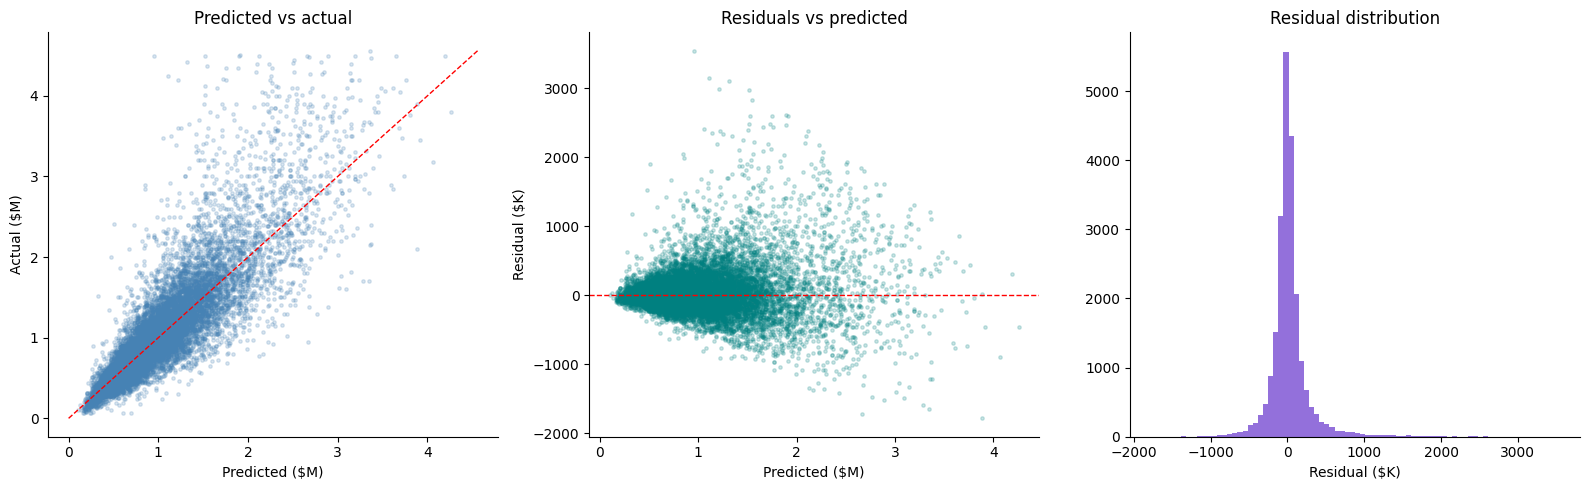

Residual mean:   $      26,918
Residual std:    $     274,959


In [25]:
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
axes[0].scatter(y_pred / 1e6, y_true / 1e6, alpha=0.2, s=6, color='steelblue')
lim = max(y_pred.max(), y_true.max()) / 1e6
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Predicted ($M)')
axes[0].set_ylabel('Actual ($M)')
axes[0].set_title('Predicted vs actual')

# Residuals vs predicted
axes[1].scatter(y_pred / 1e6, residuals / 1e3, alpha=0.2, s=6, color='teal')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted ($M)')
axes[1].set_ylabel('Residual ($K)')
axes[1].set_title('Residuals vs predicted')

# Residual distribution
axes[2].hist(residuals / 1e3, bins=80, color='mediumpurple', edgecolor='none')
axes[2].set_xlabel('Residual ($K)')
axes[2].set_title('Residual distribution')

plt.tight_layout()
plt.show()

print(f"Residual mean:   ${residuals.mean():>12,.0f}")
print(f"Residual std:    ${residuals.std():>12,.0f}")

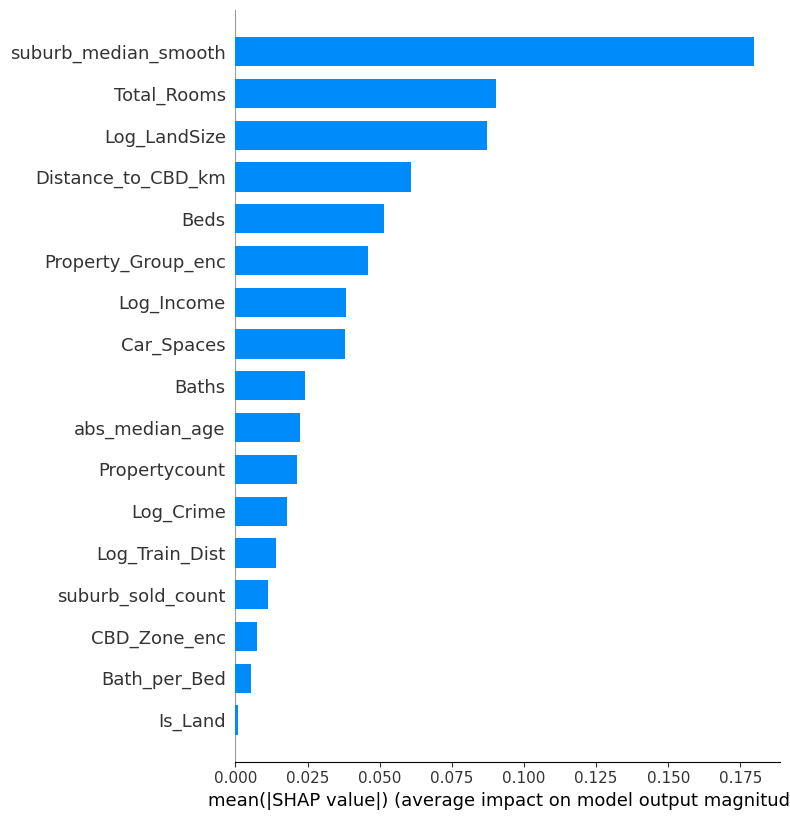

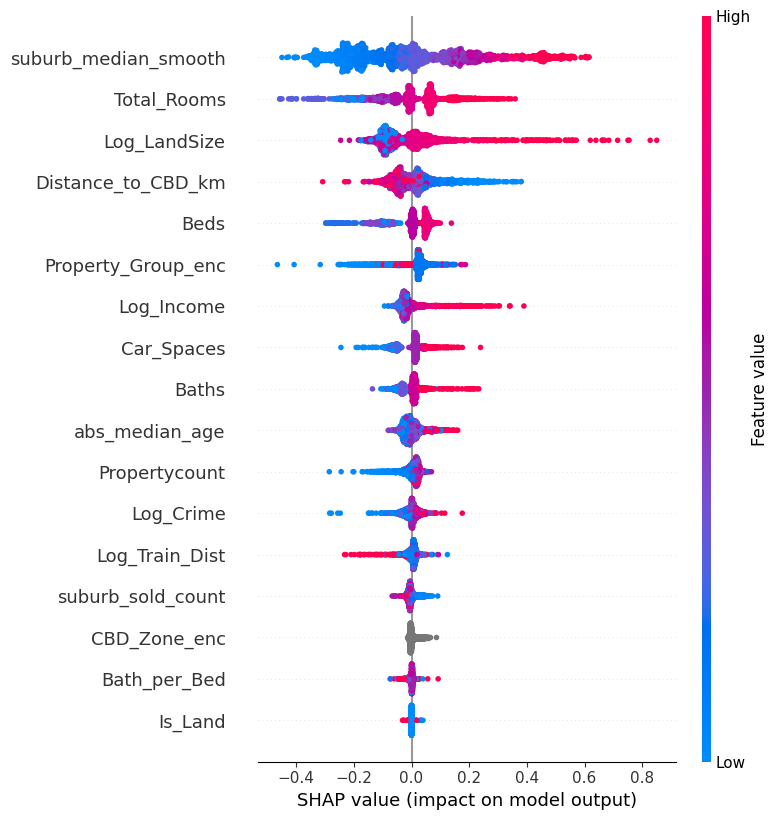

In [26]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.sample(2000, random_state=42))

shap.summary_plot(
    shap_values,
    X_test.sample(2000, random_state=42),
    feature_names=FEATURES,
    plot_type='bar',
    show=True
)

explainer = shap.TreeExplainer(best_model)
X_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    plot_type='bar',
    show=True
)

shap.summary_plot(
    shap_values,
    X_test.sample(2000, random_state=42),
    feature_names=FEATURES,
    show=True
)

In [29]:
# Prepare For Sale feature matrix
fs_features = forsale[FEATURES].copy()

# Fill any remaining NaN in features with training set medians
feature_medians = X_train.median()
fs_features = fs_features.fillna(feature_medians)

# Predict in log space, convert back
forsale['Model_Value'] = np.expm1(best_model.predict(fs_features))

# Deal score = (asking - model) / model
# Negative = asking below model estimate (potential deal)
# Positive = asking above model estimate (potential overpriced)
forsale_priced = forsale.dropna(subset=['Numeric_Price']).copy()
forsale_priced['Deal_Score_pct'] = (
    (forsale_priced['Numeric_Price'] - forsale_priced['Model_Value']) /
    forsale_priced['Model_Value'] * 100
)

print(f"For Sale listings with deal score: {len(forsale_priced):,}")
print(forsale_priced['Deal_Score_pct'].describe())

For Sale listings with deal score: 33,077
count     33077.000000
mean         16.301962
std         620.583315
min         -99.187306
25%          -4.175743
50%           3.888921
75%          16.285614
max      100235.081309
Name: Deal_Score_pct, dtype: float64


In [30]:
# Top potential underpriced listings
underpriced = forsale_priced.sort_values('Deal_Score_pct').head(20)

display_cols = [
    'Full_Address', 'Suburb', 'Property_Group',
    'Beds', 'Baths', 'LandSize_sqm',
    'Numeric_Price', 'Model_Value', 'Deal_Score_pct'
]
print("\nTop 20 most underpriced For Sale listings:")
print(underpriced[display_cols].to_string(index=False))


Top 20 most underpriced For Sale listings:
                                    Full_Address         Suburb Property_Group  Beds  Baths  LandSize_sqm  Numeric_Price  Model_Value  Deal_Score_pct
             2 Cape Court, CAPE SCHANCK VIC 3939   CAPE SCHANCK          House     5      6           NaN        10500.0 1.291999e+06      -99.187306
          10 Stockwhip Drive, TRUGANINA VIC 3029      TRUGANINA          House     4      2         382.0        10000.0 7.066102e+05      -98.584793
             17 Fenwick Street, TARNEIT VIC 3029        TARNEIT          House     4      2         350.0        10000.0 6.779578e+05      -98.524982
              53 Dunphy Street, TARNEIT VIC 3029        TARNEIT          House     4      2           NaN        10000.0 6.318791e+05      -98.417419
           65 Metroon Drive, WEIR VIEWS VIC 3338     WEIR VIEWS          House     4      2           NaN        10000.0 5.769439e+05      -98.266729
 23C/211 Powlett Street, EAST MELBOURNE VIC 3002 EAST ME

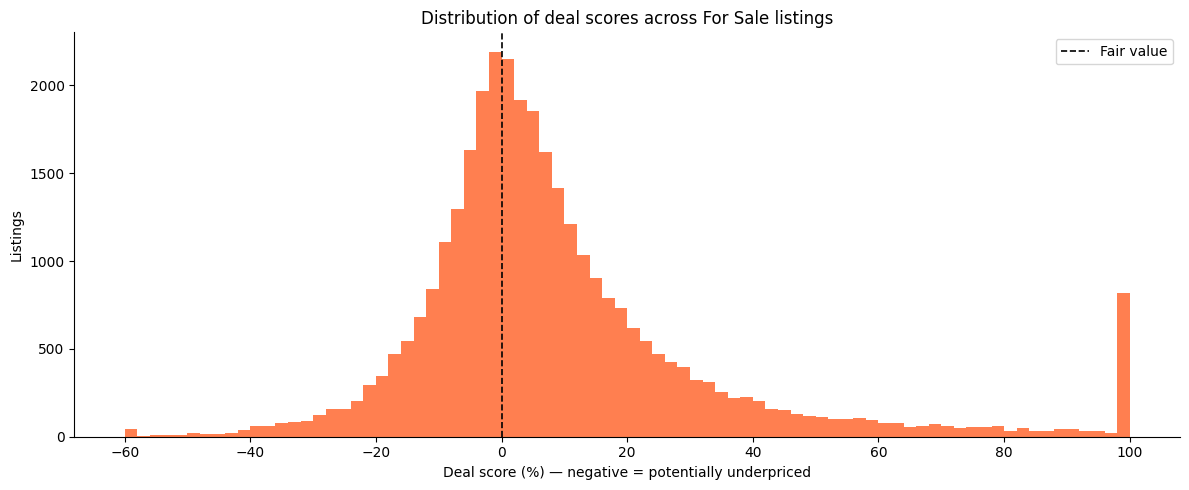

In [31]:
# Distribution of deal scores
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    forsale_priced['Deal_Score_pct'].clip(-60, 100),
    bins=80, color='coral', edgecolor='none'
)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='Fair value')
ax.set_xlabel('Deal score (%) — negative = potentially underpriced')
ax.set_ylabel('Listings')
ax.set_title('Distribution of deal scores across For Sale listings')
ax.legend()
plt.tight_layout()
plt.show()